In [ ]:
import pandas as pd

df = pd.read_csv("/content/engagement_features.csv") #task_1 file

In [ ]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (995124, 15)
Columns: ['id_student', 'week', 'sum_click', 'cum_clicks', 'active_week', 'consistency', 'last_active_week', 'recency', 'recency_score', 'diversity', 'rolling_max', 'scaled_clicks', 'trend', 'engagement_score', 'engagement_score_smooth']


,id_student,week,sum_click,cum_clicks,active_week,consistency,last_active_week,recency,recency_score,diversity,rolling_max,scaled_clicks,trend,engagement_score,engagement_score_smooth
0,6516,0,229,0.008245,1,1.0,0.0,0.0,1.0,0.428571,229,1.000000,0.000000,46.634685,NaN
1,6516,1,42,0.009757,1,1.0,1.0,0.0,1.0,0.285714,229,0.183406,0.591703,56.363691,NaN
2,6516,2,79,0.012601,1,1.0,2.0,0.0,1.0,0.357143,229,0.344978,0.509461,55.861391,52.953255
3,6516,3,193,0.019549,1,1.0,3.0,0.0,1.0,0.285714,229,0.842795,0.457060,53.915639,55.380240
4,6516,4,69,0.022033,1,1.0,4.0,0.0,1.0,0.285714,229,0.301310,0.496361,54.763769,54.846933


In [ ]:
import zipfile
import os

zip_path = "/content/anonymisedData.zip" #path for oulad dataset
extract_path = "./data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted files:", os.listdir(extract_path))

Extracted files: ['courses.csv', 'studentRegistration.csv', 'studentInfo.csv', 'studentVle.csv', 'assessments.csv', 'studentAssessment.csv', 'vle.csv']


In [ ]:
student_info = pd.read_csv("./data/studentInfo.csv")

In [ ]:
student_info["final_result"].value_counts()

,count
final_result,
Pass,12361
Withdrawn,10156
Fail,7052
Distinction,3024


In [ ]:
student_info["target"] = student_info["final_result"].map({
    "Pass": 0,
    "Distinction": 0,
    "Fail": 1,
    "Withdrawn": 1
})

In [ ]:
student_info["target"].value_counts()

,count
target,
1,17208
0,15385


In [ ]:
df = df.merge(student_info[["id_student", "target"]], on="id_student", how="left")

In [ ]:
df_model = df[df["week"] <= 6]

In [ ]:
df_agg = df_model.groupby("id_student").agg({
    "cum_clicks": "last",
    "consistency": "last",
    "recency_score": "last",
    "diversity": "mean",
    "trend": "mean",
    "engagement_score": "last",
    "target": "first"
}).reset_index()

In [ ]:
print("Max week:", df_model["week"].max())
print("Shape:", df_agg.shape)
df_agg.head()

Max week: 6
Shape: (25516, 8)


,id_student,cum_clicks,consistency,recency_score,diversity,trend,engagement_score,target
0,6516,0.023618,1.000000,1.0,0.326531,0.378561,48.165817,0
1,8462,0.015445,1.000000,1.0,0.438776,0.417582,53.652303,1
2,11391,0.014797,0.857143,1.0,0.244898,0.272573,43.590064,0
3,23629,0.001692,0.714286,0.5,0.112245,0.256729,26.646857,1
4,23698,0.007272,0.857143,0.5,0.255102,0.318707,28.181812,0


In [ ]:
df_agg.isna().sum()

,0
id_student,0
cum_clicks,0
consistency,0
recency_score,0
diversity,0
trend,0
engagement_score,0
target,0


In [ ]:
id="ftrg42"
X = df_agg.drop(columns=["id_student", "target"])
y = df_agg["target"]

In [ ]:
id="l7h33r"
print(X.shape)
print(y.shape)

(25516, 6)
(25516,)


In [ ]:
id="c2w91o"
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
id="s2mjvy"
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (20412, 6)
Test: (5104, 6)


In [ ]:
id="lf9m4r"
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
id="qv2e3d"
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
id="rj8t1x"
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Precision: 0.684979544126242
Recall: 0.48650892486508923
F1 Score: 0.5689320388349515
ROC-AUC: 0.7029147807656969


In [ ]:
id="r9c1be"
print(confusion_matrix(y_test, y_pred))

[[2156  539]
 [1237 1172]]


Why optimize for Recall?

Recall was prioritized because missing an at-risk student (false negative) is more harmful than incorrectly flagging a safe student (false positive). Early identification is critical for timely intervention.

In [ ]:
id="z9wq3d"
import numpy as np

threshold = 0.3

y_pred_new = (y_prob >= threshold).astype(int)

In [ ]:
id="t7fxc1"
print("Precision:", precision_score(y_test, y_pred_new))
print("Recall:", recall_score(y_test, y_pred_new))
print("F1:", f1_score(y_test, y_pred_new))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_new))

Precision: 0.5145493257629524
Recall: 0.9028642590286425
F1: 0.6555153707052441
Confusion Matrix:
 [[ 643 2052]
 [ 234 2175]]


In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
})

feature_importance = feature_importance.sort_values(by="coefficient", ascending=False)
feature_importance

,feature,coefficient
3,diversity,1.992056
2,recency_score,1.047982
4,trend,0.614579
5,engagement_score,-0.082112
1,consistency,-0.111262
0,cum_clicks,-3.340841


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=6, random_state=42)

In [ ]:
print("RF trained")

RF trained


In [ ]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(confusion_matrix(y_test, y_pred_rf))

Precision: 0.6702470461868958
Recall: 0.5180572851805728
F1: 0.5844064621868414
ROC-AUC: 0.7066120323369922
[[2081  614]
 [1161 1248]]


In [ ]:
threshold = 0.3
y_pred_rf_new = (y_prob_rf >= threshold).astype(int)

print("Precision:", precision_score(y_test, y_pred_rf_new))
print("Recall:", recall_score(y_test, y_pred_rf_new))
print("F1:", f1_score(y_test, y_pred_rf_new))
print(confusion_matrix(y_test, y_pred_rf_new))

Precision: 0.5091659028414299
Recall: 0.9223744292237442
F1: 0.6561346522958807
[[ 553 2142]
 [ 187 2222]]


In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:12:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

Precision: 0.6640419947506562
Recall: 0.5251141552511416
F1: 0.5864626796476587
ROC-AUC: 0.7083193743930267
[[2055  640]
 [1144 1265]]


In [ ]:
threshold = 0.3
y_pred_xgb_new = (y_prob_xgb >= threshold).astype(int)

print("Precision:", precision_score(y_test, y_pred_xgb_new))
print("Recall:", recall_score(y_test, y_pred_xgb_new))
print("F1:", f1_score(y_test, y_pred_xgb_new))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_new))

Precision: 0.5205348615090736
Recall: 0.9049398090493981
F1: 0.6609064726390784
Confusion Matrix:
 [[ 687 2008]
 [ 229 2180]]


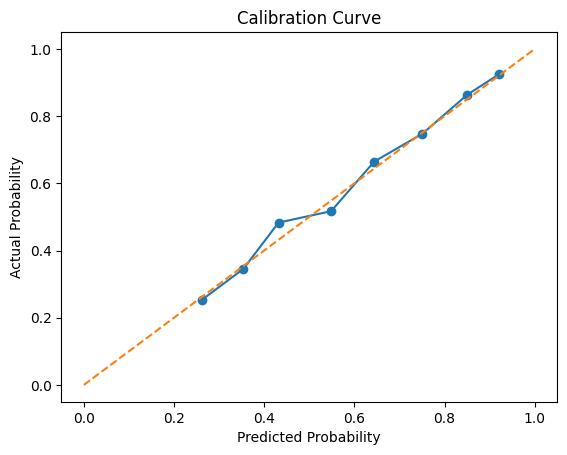

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, y_prob_rf, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')  # perfect calibration
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")
plt.title("Calibration Curve")
plt.show()

Calibration analysis

The model is reasonably calibrated: students predicted at higher risk levels (e.g., ~70%) show a correspondingly higher observed withdrawal rate. This indicates that predicted probabilities are meaningful and usable for decision-making.

In [ ]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

importance

,feature,importance
5,engagement_score,0.431767
2,recency_score,0.202421
1,consistency,0.153004
3,diversity,0.091572
4,trend,0.067441
0,cum_clicks,0.053796


Top 3 features and mechanisms

Engagement Score: Low engagement indicates reduced interaction with course materials, signaling disengagement.

Recency: Longer inactivity (time since last activity) strongly correlates with dropout risk.

Trend: A declining engagement trend reflects loss of interest or motivation over time.

In [ ]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

importance

,feature,importance
5,engagement_score,0.431767
2,recency_score,0.202421
1,consistency,0.153004
3,diversity,0.091572
4,trend,0.067441
0,cum_clicks,0.053796


In [ ]:
print("Sum of importance:", importance["importance"].sum())
print("Number of features:", len(importance))
importance

Sum of importance: 1.0
Number of features: 6


,feature,importance
5,engagement_score,0.431767
2,recency_score,0.202421
1,consistency,0.153004
3,diversity,0.091572
4,trend,0.067441
0,cum_clicks,0.053796


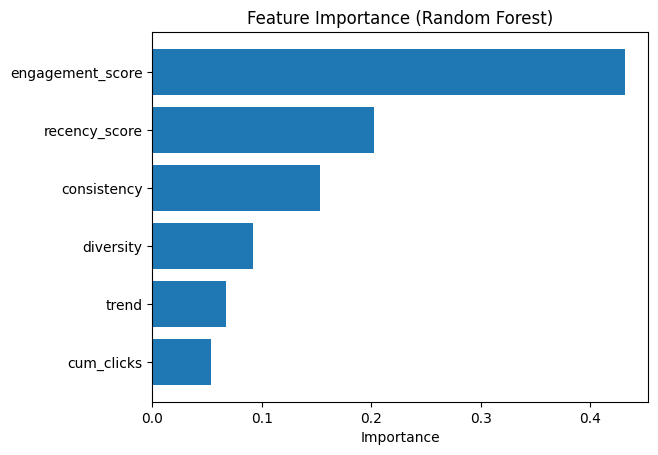

In [ ]:
import matplotlib.pyplot as plt

plt.barh(importance["feature"], importance["importance"])
plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
alerts = pd.DataFrame({
    "id_student": df_agg.loc[X_test.index, "id_student"],
    "risk_score": y_prob_rf
})

In [ ]:
alerts["alert_flag"] = alerts["risk_score"] >= 0.36

In [ ]:
alerts["alert_flag"].mean()

np.float64(0.6927899686520376)

In [ ]:
def risk_level(p):
    if p >= 0.7:
        return "High"
    elif p >= 0.4:
        return "Medium"
    else:
        return "Low"

alerts["risk_level"] = alerts["risk_score"].apply(risk_level)

In [ ]:
alerts["risk_level"].value_counts()

,count
risk_level,
Low,2441
Medium,1915
High,748


In [ ]:
features_test = df_agg.loc[X_test.index].copy()

alerts = alerts.merge(
    features_test[[
        "id_student",
        "engagement_score",
        "trend"
    ]],
    on="id_student",
    how="left"
)

In [ ]:
alerts.isna().sum()

,0
id_student,0
risk_score,0
alert_flag,0
risk_level,0
engagement_score,0
trend,0


In [ ]:
df_model_sorted = df_model.sort_values(["id_student", "week"])

df_model_sorted["last_active_week"] = df_model_sorted["week"].where(
    df_model_sorted["sum_click"] > 0
)

df_model_sorted["last_active_week"] = (
    df_model_sorted.groupby("id_student")["last_active_week"].ffill()
)

df_model_sorted["raw_recency"] = (
    df_model_sorted["week"] - df_model_sorted["last_active_week"]
)

df_model_sorted["raw_recency"] = df_model_sorted["raw_recency"].fillna(df_model_sorted["week"])

raw_recency = df_model_sorted.groupby("id_student")["raw_recency"].last().reset_index()

alerts = alerts.merge(raw_recency, on="id_student", how="left")

In [ ]:
alerts["raw_recency"].describe()

,raw_recency
count,5104.000000
mean,0.701998
std,1.481729
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,6.000000


In [ ]:
eng_threshold = alerts["engagement_score"].quantile(0.3)

alerts["low_engagement"] = alerts["engagement_score"] < eng_threshold
alerts["inactive"] = alerts["raw_recency"] >= 2
alerts["declining"] = alerts["trend"] < alerts["trend"].quantile(0.25)

In [ ]:
alerts[["low_engagement", "inactive", "declining"]].mean()

,0
low_engagement,0.299961
inactive,0.166340
declining,0.250000


In [ ]:
alerts.groupby("risk_level")[["low_engagement", "inactive", "declining"]].mean()

,low_engagement,inactive,declining
risk_level,,,
High,1.000000,0.977273,0.754011
Low,0.000410,0.000000,0.046293
Medium,0.408355,0.061619,0.312794


In [ ]:
alerts["reason"] = ""

alerts.loc[alerts["low_engagement"], "reason"] += "Low engagement; "
alerts.loc[alerts["inactive"], "reason"] += "Inactive; "
alerts.loc[alerts["declining"], "reason"] += "Declining trend; "

alerts.loc[alerts["reason"] == "", "reason"] = "No strong risk signals yet"

In [ ]:
alerts["reason"] = alerts["reason"].str.replace("; ", ", ").str.strip(", ")

In [ ]:
alerts[["risk_level", "reason"]].head(10)

,risk_level,reason
0,Low,No strong risk signals yet
1,Low,No strong risk signals yet
2,Low,No strong risk signals yet
3,Medium,No strong risk signals yet
4,Medium,No strong risk signals yet
5,Medium,Low engagement
6,Low,No strong risk signals yet
7,Low,No strong risk signals yet
8,Medium,"Low engagement, Declining trend"
9,Low,No strong risk signals yet


In [ ]:
alert_view = alerts[[
    "id_student",
    "risk_score",
    "risk_level",
    "alert_flag",
    "reason",
    "low_engagement",
    "inactive",
    "declining"
]]
alert_view.head(10)

,id_student,risk_score,risk_level,alert_flag,reason,low_engagement,inactive,declining
0,957467,0.296639,Low,False,No strong risk signals yet,False,False,False
1,543113,0.220260,Low,False,No strong risk signals yet,False,False,False
2,405784,0.260618,Low,False,No strong risk signals yet,False,False,False
3,342949,0.452843,Medium,True,No strong risk signals yet,False,False,False
4,601467,0.403014,Medium,True,No strong risk signals yet,False,False,False
5,618145,0.540486,Medium,True,Low engagement,True,False,False
6,416008,0.307132,Low,False,No strong risk signals yet,False,False,False
7,439182,0.344680,Low,False,No strong risk signals yet,False,False,False
8,265958,0.659824,Medium,True,"Low engagement, Declining trend",True,False,True
9,239345,0.290288,Low,False,No strong risk signals yet,False,False,False


Alert system design

Trigger threshold: Risk score ≥ 0.5

Advisor receives:

Student ID

Risk score

Risk level (Low / Medium / High)

Behavioral reasons (e.g., low engagement, inactivity, declining trend)

Example:

Student: 618145  
Risk Score: 0.55  
Risk Level: Medium  

Reason: Low engagement

Alerts are designed to be interpretable and actionable, enabling advisors to prioritize and intervene effectively.